In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 130,
})
 
SCENARIO_COLORS = {
    "historical": "#888",
    "ssp126":     "#9966cc",
    "ssp245":     "#f39c12",
    "ssp585":     "#c0392b",
}
SCENARIO_LABELS = {
    "historical": "Historical",
    "ssp126":     "SSP1-2.6 (low)",
    "ssp245":     "SSP2-4.5 (medium)",
    "ssp585":     "SSP5-8.5 (high)",
}

In [3]:
def load_cmip6_tas(scenario: str, model="GFDL-ESM4"):
    """
    Returns a globally-averaged annual-mean surface-air-temperature timeseries
    as a pandas Series indexed by year.
    Uses the publicly accessible CMIP6 Zarr store on GCS.
    """
    import gcsfs, xarray as xr
    gcs = gcsfs.GCSFileSystem(token="anon")
    activity = "CMIP" if scenario == "historical" else "ScenarioMIP"
    path = f"gs://cmip6/CMIP6/{activity}/NOAA-GFDL/{model}/{scenario}/r1i1p1f1/Amon/tas/gr1/v20190726"
    store = gcs.get_mapper(path)
    ds = xr.open_zarr(store, consolidated=True)
    weights = np.cos(np.deg2rad(ds.lat))
    tas_global = ds["tas"].weighted(weights).mean(dim=["lat", "lon"])
    tas_annual = tas_global.resample(time="1YE").mean()
    return pd.Series(
        tas_annual.values - 273.15,
        index=tas_annual.time.dt.year.values,
    )
 
 
def load_cmip6_map(scenario: str, year: int, model="GFDL-ESM4"):
    """Returns (lat, lon, tas_C) arrays for a given scenario and year."""
    import gcsfs, xarray as xr
    gcs = gcsfs.GCSFileSystem(token="anon")
    activity = "CMIP" if scenario == "historical" else "ScenarioMIP"
    path = f"gs://cmip6/CMIP6/{activity}/NOAA-GFDL/{model}/{scenario}/r1i1p1f1/Amon/tas/gr1/v20190726"
    ds = xr.open_zarr(gcs.get_mapper(path), consolidated=True)
    yr = ds["tas"].sel(time=str(year)).mean("time") - 273.15
    return yr.lat.values, yr.lon.values, yr.values

In [4]:
def plot1_global_temp_scenarios():
    """
    Question answered: How much does the choice of emissions scenario
    matter for global temperature by 2100?
    """
    # --- synthetic stand-in data (replace with load_cmip6_tas calls) ----------
    rng = np.random.default_rng(42)
    hist_years  = np.arange(1950, 2015)
    fut_years   = np.arange(2015, 2101)
    hist_temps  = 14.0 + np.linspace(0, 0.8, len(hist_years)) + rng.normal(0, 0.1, len(hist_years))
 
    def fut(slope, noise=0.12):
        base = hist_temps[-1] + slope * np.linspace(0, 1, len(fut_years))
        return base + rng.normal(0, noise, len(fut_years))
 
    data = {
        "historical": pd.Series(hist_temps, index=hist_years),
        "ssp126":     pd.Series(fut(0.5),   index=fut_years),
        "ssp245":     pd.Series(fut(1.5),   index=fut_years),
        "ssp585":     pd.Series(fut(3.5),   index=fut_years),
    }

    fig, ax = plt.subplots(figsize=(9, 5))
    for scen, series in data.items():
        color = SCENARIO_COLORS[scen]
        lw = 1.6 if scen == "historical" else 2.0
        ls = "--" if scen == "historical" else "-"
        ax.plot(series.index, series.values, color=color, lw=lw, ls=ls,
                label=SCENARIO_LABELS[scen])
 
    upper = data["ssp585"].values + 0.4
    lower = data["ssp585"].values - 0.4
    ax.fill_between(fut_years, lower, upper, color=SCENARIO_COLORS["ssp585"], alpha=0.12)
 
    ax.axvline(2015, color="#aaa", lw=0.8, ls=":")
    ax.text(2016, ax.get_ylim()[0] + 0.05, "projections →", fontsize=8, color="#999")
    ax.set_xlabel("Year")
    ax.set_ylabel("Global mean surface temp (°C)")
    ax.set_title("Global warming diverges sharply across emission scenarios")
    ax.legend(frameon=False, fontsize=9)
    plt.tight_layout()
    plt.show()

In [5]:
def plot2_temp_vs_precip_scatter():
    """
    Question answered: Which regions face both drying AND extreme warming?
    (the most vulnerable combination)
    """
    rng = np.random.default_rng(17)
    regions = {
        "Amazon":         (4.1,  -18),
        "Sahel":          (4.8,   -8),
        "Mediterranean":  (3.9,  -22),
        "Central Asia":   (4.3,  -12),
        "Western Europe": (3.0,    5),
        "East Africa":    (3.8,   -6),
        "South Asia":     (3.5,   10),
        "SE Asia":        (3.2,   12),
        "Arctic":         (9.2,   18),
        "Alaska":         (7.1,   15),
        "Andes":          (3.4,   -5),
        "N. Australia":   (3.7,  -14),
        "US Southwest":   (4.0,  -20),
        "Siberia":        (6.8,   10),
        "Pacific Islands":(2.9,    8),
    }
    names = list(regions.keys())
    temp  = np.array([v[0] for v in regions.values()]) + rng.normal(0, 0.15, len(names))
    prcp  = np.array([v[1] for v in regions.values()]) + rng.normal(0, 1.5,  len(names))
 
    fig, ax = plt.subplots(figsize=(8, 6))
    sc = ax.scatter(temp, prcp, c=temp, cmap="RdYlBu_r", s=80, edgecolors="#333", lw=0.4, zorder=3)
    plt.colorbar(sc, label="Warming (°C)")
 
    for i, name in enumerate(names):
        ax.annotate(name, (temp[i], prcp[i]), fontsize=7.5,
                    xytext=(5, 4), textcoords="offset points")
 
    ax.axhline(0, color="#aaa", lw=0.8, ls="--")
    ax.axvline(np.mean(temp), color="#aaa", lw=0.8, ls=":")
 
    ax.text(8.5, -25, "Extreme risk\n(hot + dry)", fontsize=8, color="#c0392b",
            ha="right", va="bottom")
    ax.text(2.5, 20,  "Relatively buffered\n(moderate + wetter)", fontsize=8,
            color="#27ae60", ha="left", va="top")
 
    ax.set_xlabel("Temperature increase by 2100 (°C, SSP5-8.5)")
    ax.set_ylabel("Precipitation change by 2100 (%)")
    ax.set_title("Compound climate risk: warming vs precipitation change by region")
    plt.tight_layout()
    plt.show()

In [6]:
def plot3_regional_small_multiples():
    """
    Question answered: How do warming trajectories differ across key regions,
    and how do scenarios diverge over time?
    """
    rng = np.random.default_rng(55)
    years = np.arange(1950, 2101)

    def make_series(base_rate, amplify=1.0):
        n = len(years)
        hist_end = np.where(years == 2014)[0][0] + 1
        hist = base_rate * amplify * np.linspace(0, 0.9, hist_end) + rng.normal(0, 0.08, hist_end)
        fut_n = n - hist_end
        fut126 = hist[-1] + amplify * 0.5 * np.linspace(0, 1, fut_n) + rng.normal(0, 0.08, fut_n)
        fut245 = hist[-1] + amplify * 1.5 * np.linspace(0, 1, fut_n) + rng.normal(0, 0.1,  fut_n)
        fut585 = hist[-1] + amplify * 3.5 * np.linspace(0, 1, fut_n) + rng.normal(0, 0.12, fut_n)
        return hist, fut126, fut245, fut585

    panels = {
        "Arctic":          make_series(1.0, amplify=2.5),
        "Mediterranean":   make_series(1.0, amplify=1.3),
        "Tropics":         make_series(1.0, amplify=0.8),
        "Global mean":     make_series(1.0, amplify=1.0),
    }

    fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)
    axes = axes.flatten()
    hist_idx = np.where(years <= 2014)[0]
    fut_idx  = np.where(years > 2014)[0]

    for ax, (region, (hist, f126, f245, f585)) in zip(axes, panels.items()):
        ax.plot(years[hist_idx], hist, color="#888", lw=1.4, label="Historical")
        fut_years = years[fut_idx]
        hval = hist[-1]
        for f, scen in [(f126, "ssp126"), (f245, "ssp245"), (f585, "ssp585")]:
            ts = np.concatenate([[hval], f])
            yr = np.concatenate([[2014], fut_years])
            ax.plot(yr, ts, color=SCENARIO_COLORS[scen], lw=1.6,
                    label=SCENARIO_LABELS[scen])
        ax.axvline(2014, color="#bbb", lw=0.7, ls=":")
        ax.set_title(region, fontsize=10, fontweight="bold")
        ax.set_xlabel("Year", fontsize=8)
        ax.set_ylabel("Δ Temp (°C)", fontsize=8)
        ax.tick_params(labelsize=8)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=8, frameon=False)
    fig.suptitle("Warming trajectories by region and scenario", fontsize=12, y=1.01)
    plt.show()

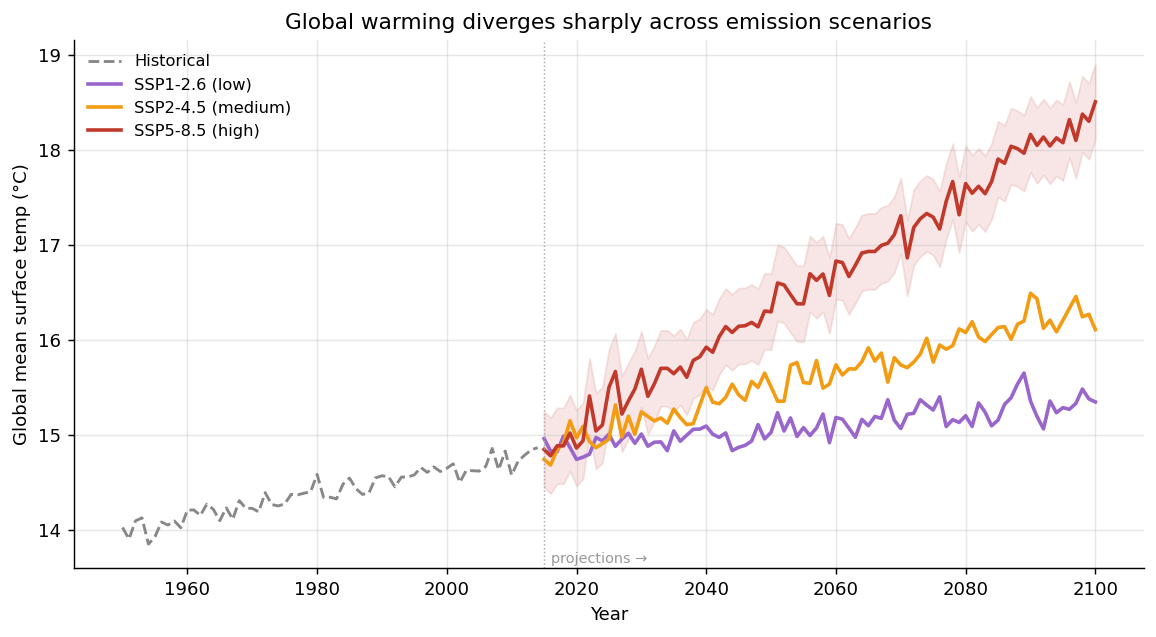

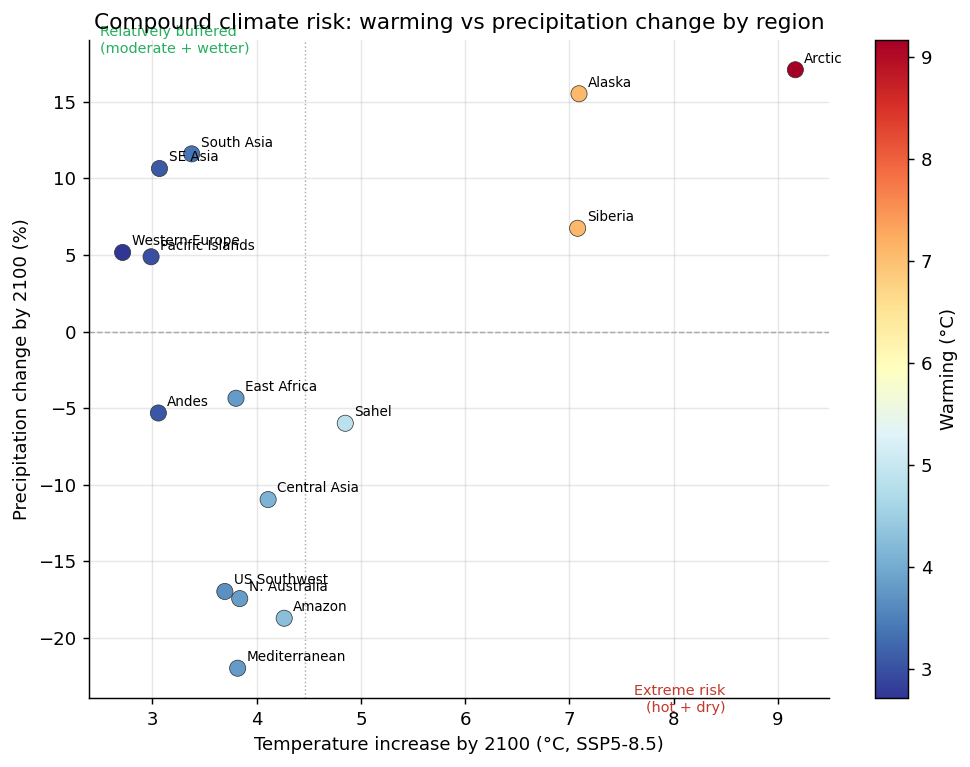

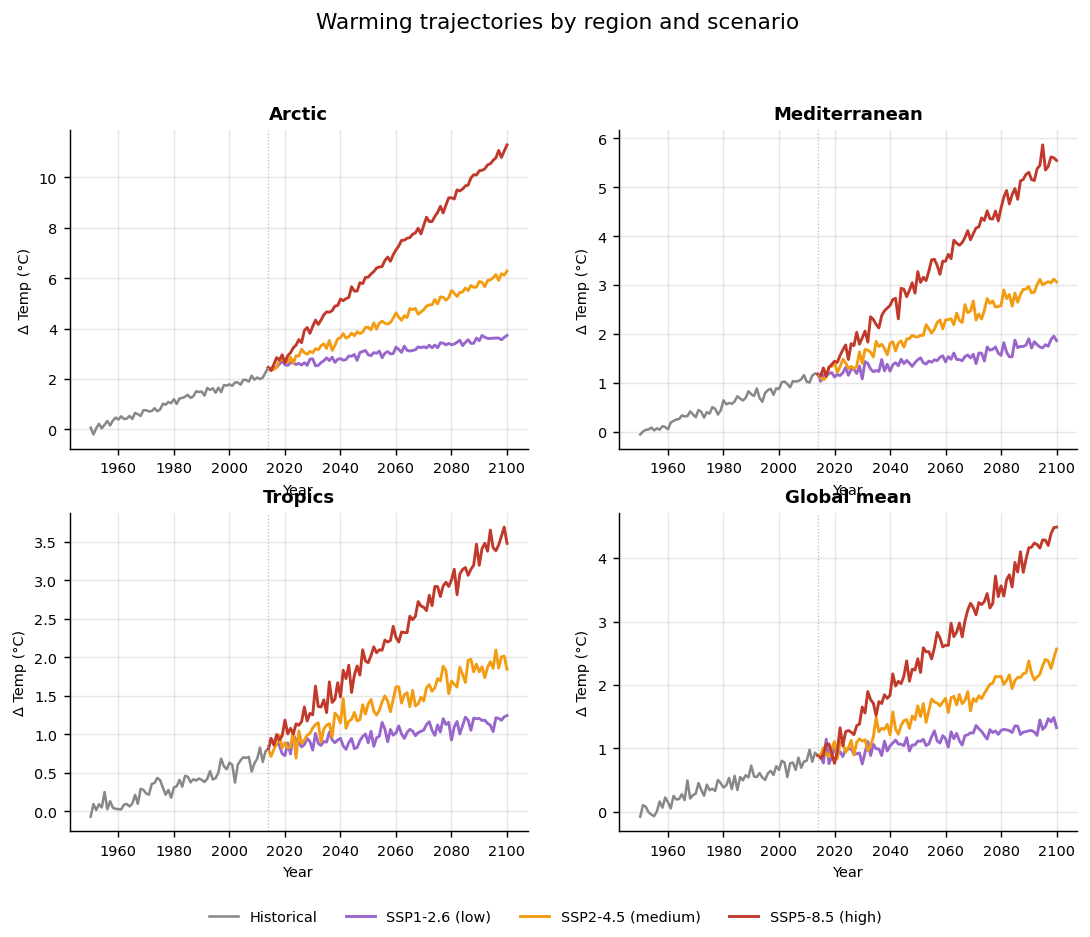

In [7]:
if __name__ == "__main__":
    plot1_global_temp_scenarios()
    plot2_temp_vs_precip_scatter()
    plot3_regional_small_multiples()